<a href="https://colab.research.google.com/github/JencilJ/PythonProject3/blob/main/PythonProject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("/content/NYPD_Arrest_Data_(Year_to_Date)_20260608.csv")

In [6]:
df.head(10)

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)
5,318772893,01/12/2026,263.0,"ARSON 2,3,4",114.0,ARSON,PL 1501001,F,M,28,0,25-44,M,BLACK,998296,234474,40.810250,-73.949261,POINT (-73.949261 40.81025)
6,318824413,01/13/2026,548.0,"GAMBLING, DEVICE, POSSESSION",350.0,GAMBLING,PL 2253001,M,B,41,0,25-44,M,BLACK HISPANIC,1014777,235863,40.814023,-73.889715,POINT (-73.889715 40.814023)
7,319446124,01/25/2026,777.0,(null),NaN,(null),PL 1950200,F,K,67,0,25-44,F,BLACK,997897,175676,40.648867,-73.950822,POINT (-73.950822 40.648867)
8,319291106,01/22/2026,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200600,F,S,120,0,<18,F,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
9,319730888,02/01/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1600500,F,Q,103,0,25-44,M,BLACK,1038009,194117,40.699330,-73.806123,POINT (-73.806123 40.69933)


In [7]:
df.describe()

,ARREST_KEY,PD_CD,KY_CD,ARREST_PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,6.930500e+04,69303.000000,69293.000000,69305.000000,69305.000000,6.930500e+04,69305.000000,69305.000000,69305.000000
mean,3.204493e+08,458.246786,262.637741,63.387634,0.899690,1.005511e+06,207575.198485,40.736418,-73.922995
std,1.309817e+06,279.603446,149.718811,34.077372,6.560605,2.229968e+04,29859.100884,0.081820,0.074304
min,3.182079e+08,9.000000,101.000000,1.000000,0.000000,-7.400000e+01,40.000000,40.505195,-74.253049
25%,3.193060e+08,199.000000,117.000000,40.000000,0.000000,9.907960e+05,184962.000000,40.674266,-73.976437
50%,3.204358e+08,439.000000,341.000000,66.000000,0.000000,1.005390e+06,204948.000000,40.729067,-73.923689
75%,3.215846e+08,744.000000,344.000000,90.000000,0.000000,1.017119e+06,236070.000000,40.814611,-73.881510
max,3.227481e+08,969.000000,995.000000,123.000000,97.000000,1.067306e+06,271303.000000,40.911307,-73.700287


In [8]:
df.count()

,0
ARREST_KEY,69305
ARREST_DATE,69305
PD_CD,69303
PD_DESC,69305
KY_CD,69293
OFNS_DESC,69305
LAW_CODE,69305
LAW_CAT_CD,69038
ARREST_BORO,69305
ARREST_PRECINCT,69305


In [9]:
grouped_df = df.groupby(['ARREST_BORO', 'OFNS_DESC', 'PERP_SEX']).size().reset_index(name='count')
print(grouped_df.head())

  ARREST_BORO            OFNS_DESC PERP_SEX  count
0           B               (null)   (null)      1
1           B               (null)        F      1
2           B               (null)        M      2
3           B  ADMINISTRATIVE CODE   (null)      3
4           B  ADMINISTRATIVE CODE        M      2


In [10]:
grouped_df = grouped_df.dropna()
print(grouped_df.head())

  ARREST_BORO            OFNS_DESC PERP_SEX  count
0           B               (null)   (null)      1
1           B               (null)        F      1
2           B               (null)        M      2
3           B  ADMINISTRATIVE CODE   (null)      3
4           B  ADMINISTRATIVE CODE        M      2


In [12]:
import numpy as np

# Replace the string '(null)' with actual NaN values in the grouped_df
grouped_df = grouped_df.replace('(null)', np.nan)

# Now, drop rows where any of the specified columns have NaN values
grouped_df = grouped_df.dropna(subset=['ARREST_BORO', 'OFNS_DESC', 'PERP_SEX'])

print(grouped_df.head())

   ARREST_BORO                       OFNS_DESC PERP_SEX  count
4            B             ADMINISTRATIVE CODE        M      2
6            B  ALCOHOLIC BEVERAGE CONTROL LAW        F      1
7            B  ALCOHOLIC BEVERAGE CONTROL LAW        M      4
9            B           ANTICIPATORY OFFENSES        F     11
10           B           ANTICIPATORY OFFENSES        M     60


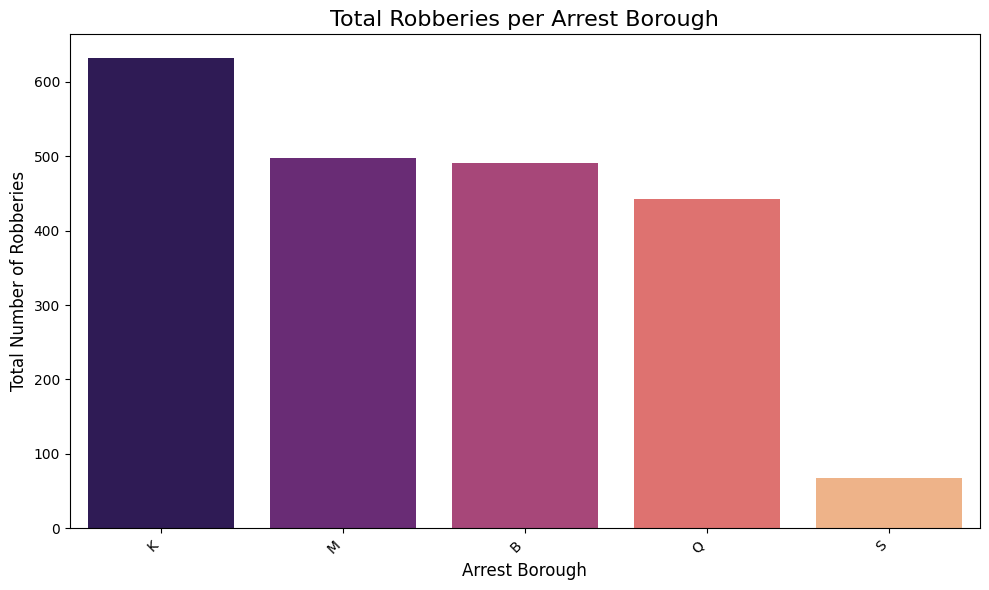

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for 'ROBBERY' offenses
robberies_df = grouped_df[grouped_df['OFNS_DESC'] == 'ROBBERY']

# Group by ARREST_BORO and sum the counts for total robberies
total_robberies_per_borough = robberies_df.groupby('ARREST_BORO')['count'].sum().reset_index()

# Sort for better visualization
total_robberies_per_borough = total_robberies_per_borough.sort_values(by='count', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='ARREST_BORO', y='count', data=total_robberies_per_borough, palette='magma', hue='ARREST_BORO', legend=False)

# Add title and labels
plt.title('Total Robberies per Arrest Borough', fontsize=16)
plt.xlabel('Arrest Borough', fontsize=12)
plt.ylabel('Total Number of Robberies', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#This analysis was showing the total number of robbery related arrests in each borough